In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

# plt.rcParams['font.family'] = "Times New Roman"

base_dir = os.path.join("./saved_models")
data_dir = os.path.join(base_dir, "metrics.pickle")

In [2]:
def get_gradient_profile_matrix(result_path):
    with open(result_path, 'rb') as handle:
        result = pickle.load(handle)

    gradient_profile_matrices = []
    for c_round_data in result.items():
        gradient_profile_matrices.append(c_round_data[1]["reduced_gradient_profile_matrix"])

    return gradient_profile_matrices

def get_cluster_id_matrix(result_path):
    with open(result_path, 'rb') as handle:
        result = pickle.load(handle)

    changes_of_estimated_cluster_ids = []
    for c_round_data in result.items():
        changes_of_estimated_cluster_ids.append(c_round_data[1]["estimated_cluster_ids"])
    changes_of_estimated_cluster_ids = np.squeeze(changes_of_estimated_cluster_ids)
    changes_of_estimated_cluster_ids = changes_of_estimated_cluster_ids.T
    return changes_of_estimated_cluster_ids


In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

gradient_profile_matrices = get_gradient_profile_matrix(data_dir)
cluster_ids = get_cluster_id_matrix(data_dir)
num_iter = len(gradient_profile_matrices)
n_models, n_clients = gradient_profile_matrices[0].shape

matching_dict = {
    0: 'r',
    1: 'orange',
    2: 'g',
    3: 'b',
}

print("training iterations: {}, number of models: {}, number of clients: {}".format(num_iter, n_models, n_clients))

# # Random projection to 3-D space
# random_projection_matrix = np.random.random((3, n_models))
# gradient_profile_matrices = [np.matmul(random_projection_matrix, gradient_profile_matrix).T for gradient_profile_matrix in gradient_profile_matrices]

# PCA dim reduction
pca = PCA(n_components=3)
gradient_profile_matrices = [pca.fit_transform(gradient_profile_matrix.T) for gradient_profile_matrix in gradient_profile_matrices]

# # TSN-E dim reduction
# tnse = TSNE(n_components=3, perplexity=3)
# gradient_profile_matrices = [tnse.fit_transform(gradient_profile_matrix.T) for gradient_profile_matrix in gradient_profile_matrices]

training iterations: 200, number of models: 4, number of clients: 12


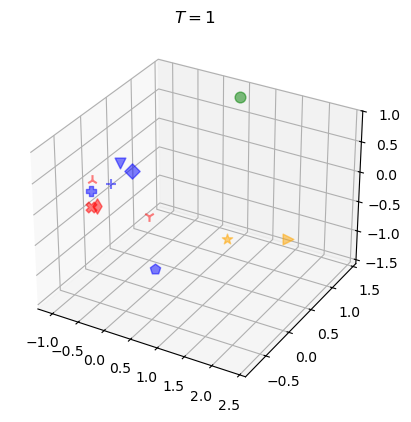

In [4]:
## Plotting single figure (3d)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

### THIS MUST BE THE RESULT OF CLUSTERING AFTER TRAINING
total_n_clusters = 12
time_step=0
# projected_G = gradient_profile_matrices[time_step].T
projected_G = gradient_profile_matrices[time_step]
markers = ['o', 'p', 'd', 'D', 'X', 'P', '1', '2', '+', '*', '>', 'v']
colors = [matching_dict[cluster] for cluster in cluster_ids[:,time_step]]
for cluster_id in range(12):
    ax.scatter(projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 0],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 1],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 2],
                            s=60, marker=markers[cluster_id], color=colors[cluster_id],
                            label="A client with cluster id {}".format(cluster_id), alpha=0.5)

plt.title(f'$T={time_step+1}$')
# Show plot
plt.show()

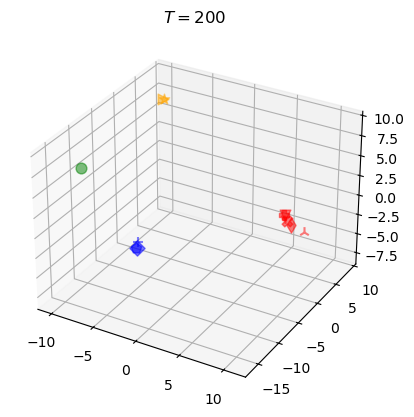

In [7]:
## Plotting single figure (3d)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

### THIS MUST BE THE RESULT OF CLUSTERING AFTER TRAINING
total_n_clusters = 12
time_step=199
# projected_G = gradient_profile_matrices[time_step].T
projected_G = gradient_profile_matrices[time_step]
markers = ['o', 'p', 'd', 'D', 'X', 'P', '1', '2', '+', '*', '>', 'v']
colors = [matching_dict[cluster] for cluster in cluster_ids[:,time_step]]
for cluster_id in range(12):
    ax.scatter(projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 0],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 1],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 2],
                            s=60, marker=markers[cluster_id], color=colors[cluster_id],
                            label="A client with cluster id {}".format(cluster_id), alpha=0.5)

plt.title(f'$T={time_step+1}$')
# Show plot
plt.show()

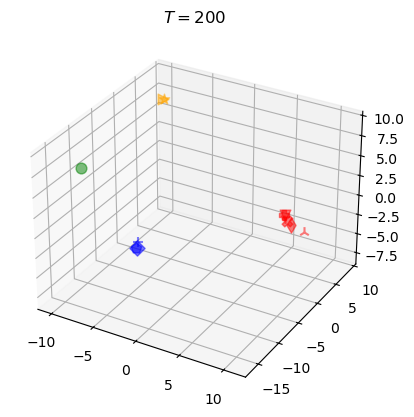

In [18]:
## Plotting single figure (3d)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

### THIS MUST BE THE RESULT OF CLUSTERING AFTER TRAINING
total_n_clusters = 12
time_step=199
# projected_G = gradient_profile_matrices[time_step].T
projected_G = gradient_profile_matrices[time_step]
markers = ['o', 'p', 'd', 'D', 'X', 'P', '1', '2', '+', '*', '>', 'v']
colors = [matching_dict[cluster] for cluster in cluster_ids[:,time_step]]
for cluster_id in range(12):
    ax.scatter(projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 0],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 1],
                            projected_G[cluster_id*(n_clients//total_n_clusters):(cluster_id+1)*(n_clients//total_n_clusters), 2],
                            s=60, marker=markers[cluster_id], color=colors[cluster_id],
                            label="A client with cluster id {}".format(cluster_id), alpha=0.5)

plt.title(f'$T={time_step+1}$')
# Show plot
plt.show()